# Guides to LiDAR (Part 3 - Using PDAL library)

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Introduction" data-toc-modified-id="Introduction-1">Introduction</a></span><ul class="toc-item"><li><span><a href="#Basic-Concepts" data-toc-modified-id="Basic-Concepts-1.1">Basic Concepts</a></span></li><li><span><a href="#EPT" data-toc-modified-id="EPT-1.2">EPT</a></span></li><li><span><a href="#Pipelines" data-toc-modified-id="Pipelines-1.3">Pipelines</a></span></li><li><span><a href="#Summary-of-Steps" data-toc-modified-id="Summary-of-Steps-1.4">Summary of Steps</a></span></li></ul></li><li><span><a href="#Step-0.-Preparation" data-toc-modified-id="Step-0.-Preparation-2">Step 0. Preparation</a></span><ul class="toc-item"><li><span><a href="#Install-the-PDAL-Package" data-toc-modified-id="Install-the-PDAL-Package-2.1">Install the PDAL Package</a></span></li><li><span><a href="#Download-the-sample-data" data-toc-modified-id="Download-the-sample-data-2.2">Download the sample data</a></span></li><li><span><a href="#Test-environment-and-data" data-toc-modified-id="Test-environment-and-data-2.3">Test environment and data</a></span></li><li><span><a href="#Explore-the-study-area" data-toc-modified-id="Explore-the-study-area-2.4">Explore the study area</a></span></li></ul></li><li><span><a href="#Step-1.-Decompress-LAZ-to-LAS" data-toc-modified-id="Step-1.-Decompress-LAZ-to-LAS-3">Step 1. Decompress LAZ to LAS</a></span><ul class="toc-item"><li><span><a href="#Visualize-point-clouds-in-plas.io" data-toc-modified-id="Visualize-point-clouds-in-plas.io-3.1">Visualize point clouds in plas.io</a></span></li><li><span><a href="#Visualize-point-clouds-in-Map-Widget" data-toc-modified-id="Visualize-point-clouds-in-Map-Widget-3.2">Visualize point clouds in Map Widget</a></span><ul class="toc-item"><li><span><a href="#Publish-LAS-file" data-toc-modified-id="Publish-LAS-file-3.2.1">Publish LAS file</a></span></li><li><span><a href="#Modify-web-scene-json" data-toc-modified-id="Modify-web-scene-json-3.2.2">Modify web scene json</a></span></li><li><span><a href="#Visualize-in-map-widget" data-toc-modified-id="Visualize-in-map-widget-3.2.3">Visualize in map widget</a></span></li></ul></li></ul></li><li><span><a href="#Step-2.-Identify-ground-V.S.-non-ground" data-toc-modified-id="Step-2.-Identify-ground-V.S.-non-ground-4">Step 2. Identify ground V.S. non-ground</a></span></li><li><span><a href="#Step-3.-Generating-a-DTM" data-toc-modified-id="Step-3.-Generating-a-DTM-5">Step 3. Generating a DTM</a></span></li><li><span><a href="#Step-4.-Reading-data-from-EPT-+-Pipelined-processing" data-toc-modified-id="Step-4.-Reading-data-from-EPT-+-Pipelined-processing-6">Step 4. Reading data from EPT + Pipelined processing</a></span><ul class="toc-item"><li><span><a href="#4.1-Create-a-file-called-dc.json-with-the-following-content:" data-toc-modified-id="4.1-Create-a-file-called-dc.json-with-the-following-content:-6.1">4.1 Create a file called dc.json with the following content:</a></span></li><li><span><a href="#4.2-Stages-walk-through" data-toc-modified-id="4.2-Stages-walk-through-6.2">4.2 Stages walk-through</a></span><ul class="toc-item"><li><span><a href="#readers.ept" data-toc-modified-id="readers.ept-6.2.1">readers.ept</a></span></li><li><span><a href="#filters.range" data-toc-modified-id="filters.range-6.2.2">filters.range</a></span></li><li><span><a href="#filters.assign" data-toc-modified-id="filters.assign-6.2.3">filters.assign</a></span></li><li><span><a href="#filters.reprojection" data-toc-modified-id="filters.reprojection-6.2.4">filters.reprojection</a></span></li><li><span><a href="#filters.smrf" data-toc-modified-id="filters.smrf-6.2.5">filters.smrf</a></span></li><li><span><a href="#filters.range" data-toc-modified-id="filters.range-6.2.6">filters.range</a></span></li><li><span><a href="#writers.gdal" data-toc-modified-id="writers.gdal-6.2.7">writers.gdal</a></span></li><li><span><a href="#writers.las" data-toc-modified-id="writers.las-6.2.8">writers.las</a></span></li></ul></li><li><span><a href="#4.3-Execute-the-Pipeline" data-toc-modified-id="4.3-Execute-the-Pipeline-6.3">4.3 Execute the Pipeline</a></span></li><li><span><a href="#4.4-Colorize-the-DEM" data-toc-modified-id="4.4-Colorize-the-DEM-6.4">4.4 Colorize the DEM</a></span></li></ul></li><li><span><a href="#References" data-toc-modified-id="References-7">References</a></span></li></ul></div>

`PDAL` is an open source Point Data Abstraction Library, written in C/C++, and its API and command lines are originally aimed for translating and processing point cloud data<a href="#References">[1]</a>. Allowing users to compose operations on point clouds into `pipelines` of stages, of which pipelines can be written in a declarative JSON syntax or constructed using the available API, `PDAL` has been a flexible tool in handling the translation, analysis, georeferencing, and batch-processing of point clouds. In the following, let's go through some basic concepts and two advanced topics of PDAL before diving into the real implementations.


## Introduction

### Basic Concepts

LiDAR systems, generally come in one of three types:
  - `Pulse-based`, or `linear-mode`, systems emit a pulse of laser energy and measure the time it takes for that energy to travel to a target, bounce off the target, and be returned to the sensor. These systems are called linear-mode because they (generally) only have a single aperture, and so can only measure distance along a single vector at any point in time. Pulse-based systems are very common, and are usually what you would think of when you think of LiDAR.
  - `Phase-based` LiDAR systems measure distance via interferometry, that is, by using the phase of a modulated laser beam to calculate a distance as a fraction of the modulated signal’s wavelength. Phase-based systems can be very precise, on the order of a few millimeters, but since they require comparatively more energy than the other two types they are usually used for short-range (e.g. indoor) scanning.
  - `Geiger-mode`, or `photon-counting`, systems use extremely sensitive detectors that can be triggered by a single photon. Since only a single photon is required to trigger a measurement, these systems can operate at much much higher altitudes than linear mode systems. However, Geiger-mode systems are relatively new and suffer from very high amounts of noise and other operational restrictions, making them significantly less common than linear-mode systems.

Talking about how LiDAR signals are collected, they are commonly categorized into four subjective types:
  - `Terrestrial LiDAR Scanning` (TLS): scanning with a stationary LiDAR sensor, usually mounted on a tripod.
  - `Airborne LiDAR scanning` (ALS): also called airborne laser swath mapping (ALSM), scanning with a LiDAR scanner mounted to a fixed-wing or rotor aircraft.
  - `Mobile LiDAR scanning` (MLS): scanning from a ground-based vehicle, such as a car.
  - `Unmanned LiDAR scanning` (ULS): scanning with drones or other unmanned vehicles.

In this notebook, when we talk about a LiDAR scanner in this program, we will be referring to a pulse-based (linear) system; and for collecting methods, we will only focus on airborne laser scanning (ALS).


### EPT

With `PDAL`, input data can be read from the `Entwine Point Tile (EPT)`<a href="#References">[2]</a> resource at https://usgs.entwine.io directly provided the accessible URL using `readers.ept` and filtered through a number of steps until processing is complete. The output data are then written to an .laz and .tif files. On the resource website, full state data are provided for <a href="https://usgs.entwine.io/data/view.html?r=https://s3-us-west-2.amazonaws.com/usgs-lidar-public/IA_FullState&m=5&cf=%5B7,49%5D">Iowa</a>, <a href="https://usgs.entwine.io/data/view.html?r=https://s3-us-west-2.amazonaws.com/usgs-lidar-public/MN_FullState&m=5&cf=%5B7,49%5D">Minnesota</a> and <a href="https://usgs.entwine.io/data/view.html?r=https://s3-us-west-2.amazonaws.com/usgs-lidar-public/KY_FullState&m=5&cf=%5B7,49%5D">Kentucky</a>, while for other states, only partial point cloud data are accessible<a href="#References">[3]</a>.

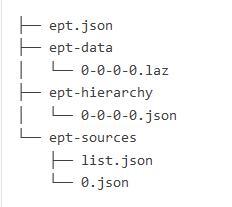
Fig 1. The organization of and EPT dataset contains JSON metadata portions as well as binary point data. This structure for a small dataset is shown in Fig 1 (Source: <a href="#References">[2]</a>).


### Pipelines

The concept of `pipelines` here is to describe the reading, filtering, and writing of point cloud data using `PDAL`. When a pipeline is constructed, a number of things can be executed in succession. A `pipeline` provides useful advantages for many workflows:
  - It becomes a record of the operation(s) applied to the data;
  - A skeleton of an operation and substitute specific options (filenames, for example) is hence constructed;
  - Users can compose complex operations using the JSON manipulation facilities of whatever language they want.


<img src="https://pdal.io/_images/pipeline-example-overview.png" width=50% height=50% />
Fig 2. Pipeline diagram. The EPT data for Iowa is fed into the pipeline using readers.ept and filtered through a number of steps until processing is complete, then written to an iowa.laz and iowa.tif file (Source: <a href="#References">[3]</a>).


### Summary of Steps

Next, in this notebook, we will be using PDAL to achieve these goals:
 1. Decompress .laz to .las files
 2. Identify ground V.S. non-ground
 3. Create DTM
 4. Generate Hillshade

Also, for management and visualization purposes, we will be using ArcGIS API for Python and arcpy commands to  - 
 - a. Create LAS Dataset
 - b. Create scene layer packages
 - c. Publish as scene layer
 - d. Share as web scene
 - e. View the web scene in the map widget
 
Before diving into the detailed steps, let's first install the PDAL library, and download the sample data in the following step.

## Step 0. Preparation

### Install the PDAL Package

A PDAL package based on the latest release, including all recent patches, is pushed to the `conda-forge` channel on `anaconda.org` with every code change on the PDAL maintenance branch. So to install the PDAL package, we just need to run the following command to (1) create an environment named `my-new-env`, installing PDAL from the conda-forge channel, or (2) install PDAL to an existing environment names `my-existing-env`:

```
(1) conda create --yes --name my-new-env --channel conda-forge pdal
```
or
```
(2) conda install --name my-existing-env --channel conda-forge pdal
```

### Download the sample data

Use the following command (on Windows OS) if in need of some sample data to play with:

```
explorer.exe https://github.com/PDAL/data/raw/master/autzen/autzen.laz
```

The downloaded `autzen.laz` file will be then found in the browser's default `downloads` folder.


### Test environment and data

If the environment is correctly configured, and the data downloaded smoothly, we can then go on to test with a simple command line:

In [ ]:
!pdal info <Downloads Folder>\autzen.laz -p 0

### Explore the study area

The downloaded point clouds are based on a stadium - Alton Baker Park - which is located in Eugene, Oregon. The stadium viewed in Google Map is like <a href="https://www.google.com/maps/place/Alton+Baker+Park/@44.0625772,-123.0697496,273a,35y,159.37h,60.61t/data=!3m1!1e3!4m5!3m4!1s0x0:0x8fe06653c480e460!8m2!3d44.0563748!4d-123.0818158">this</a>.

## Step 1. Decompress LAZ to LAS

With `LAS` being a fluffy binary format, and also the way LAS data are stored, there is ample redundant information that can be compressed. `LASzip` is an open source solution for compressing this information. Typical `LASzip` compression is 5:1 to 8:1, depending on the type of LiDAR. It is a compression format specifically for the ASPRS LAS model. Compressing a LAZ file into LAS format would have saved memory spaces in storing.

Vice Versa, by converting LAZ to LAS data, we are inflating the data. Since most of point cloud data have been stored and downloaded as `LAZ` format, we would need to convert them into `LAS` in order to create the LAS Dataset with.

In the `conda shell`, type in the commands below to perform decompression:

In [ ]:
!cd <working_directory>
!pdal translate ./autzen.laz ./autzen.las

Then use `ls` command to see if the .las file is actually an inflated version of the .laz file:

In [ ]:
!ls -alh ./autzen.laz
!ls -alh ./autzen.las

### Visualize point clouds in plas.io

Once the .las file is created, you can use one of the point cloud visualization tools you installed to take a look at your .las output, e.g. ArcGIS Pro. Or you can open the file to view it using the http://plas.io website.

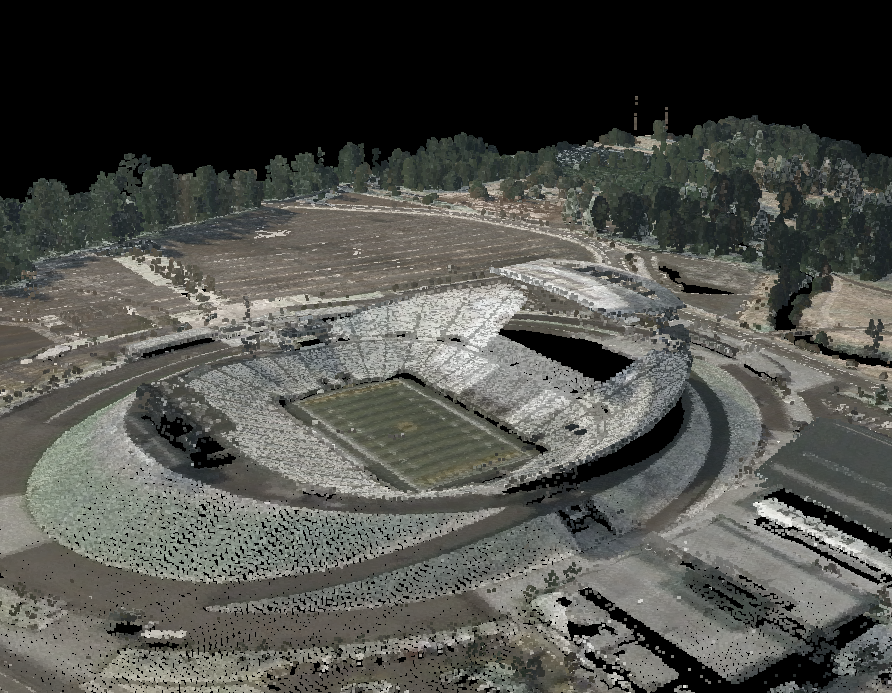


There is also an `Enable Inundation` button with which you can draw an inundation plane in the scene, and the plane can be configured for its transparency and moved up/down depending on the slider widget. This utility can be used to create a reference for elevation comparison between objects shown in the scene.

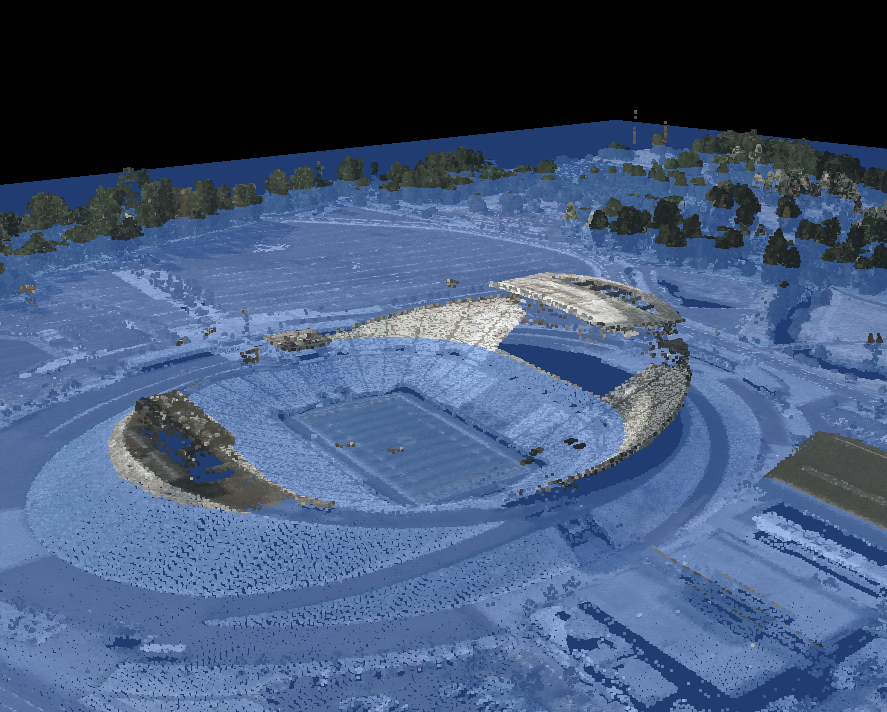

### Visualize point clouds in Map Widget

In order to visualize the point clouds (.las) file in the notebook's map widget, we have to accomplish these tasks:
 - a. Create LAS Dataset
 - b. Create scene layer packages
 - c. Publish as scene layer
 - d. Share as web scene
 - e. View the web scene in the map widget
 
The function `publish_las_file` to be defined below would have done tasks a, b, and c. Then we just need to do tasks d and e with the published scene layer. Let's now get started!

#### Publish LAS file

In [1]:
import os
import arcpy
from arcgis.gis import GIS

gis = GIS("https://www.arcgis.com", "arcgis_python", "P@ssword123", verify_cert = False)

In [26]:
def publish_las_file(las_file_name, working_dir, is_laz = False):
    
    # get the base name
    las_list_str = os.path.join(working_dir, las_file_name)
    base=os.path.basename(os.path.join(working_dir, las_file_name))
    las_file_name_base = os.path.splitext(base)[0]
    # create the path to store the LAS Dataset
    out_lasd_folder = os.path.join(working_dir, las_file_name_base + "_collection")
    out_lasd_path = os.path.join(out_lasd_folder, las_file_name_base+".lasd")
    # path to store the slpk
    out_slpk_path = os.path.join(out_lasd_folder, las_file_name_base+".slpk")

    if is_laz:
        os.mkdir(out_lasd_folder)
        arcpy.conversion.ConvertLas(las_list_str, 
                                    las_file_name_base + '_collection', 
                                    '1.4', 7, 'NO_COMPRESSION',
                                    ['REMOVE_VLR', 'REMOVE_EXTRA_BYTES', 'REARRANGE_POINTS'], 
                                    out_lasd_path)
    else:
        arcpy.CreateLasDataset_management(os.path.join(out_lasd_folder, las_file_name), 
                                          out_lasd_path, "RECURSION",
                                          compute_stats="COMPUTE_STATS")
    
    print(out_lasd_path, out_slpk_path)
    arcpy.management.CreatePointCloudSceneLayerPackage(out_lasd_path, 
                                                       out_slpk_path, 
                                                       attributes="INTENSITY;RGB;CLASS_CODE;RETURNS", 
                                                       xy_max_error_m=0.01, z_max_error_m=0.01, 
                                                       scene_layer_version="1.x")

    arcpy.management.SharePackage(out_slpk_path, 
                                  '', "*****", "slpk", "slpk", '', 
                                  "EVERYBODY", None, "MYORGANIZATION", "TRUE", '')
    
    print(arcpy.GetMessages())

In [27]:
publish_las_file("autzen.las", r'<Download Folder>\')

Start Time: Tuesday, November 19, 2019 4:09:26 PM
Succeeded at Tuesday, November 19, 2019 4:10:42 PM (Elapsed Time: 1 minutes 16 seconds)


In [30]:
scene_layer_item = gis.content.get("d5de7c090a1b43ac91bf378e151c454e")
scene_layer_item

<Item title:"autzen" type:Scene Layer owner:arcgis_python>

#### Modify web scene json

In [189]:
from arcgis.widgets import MapView
mv0 = MapView(mode="3D", gis = gis)

<Item title:"City of Eugene - 2013 3-Inch Aerials" type:Map Image Layer owner:cewmetc>
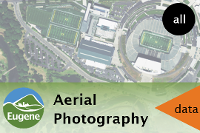

In [190]:
item_2d = gis.content.get('3da07af4428c4506afb3b362b05fbd90')
item_2d

In [191]:
item_2d.layers[0].url

'https://gis.eugene-or.gov/arcgis/rest/services/Common/CEAerials13Tiled/MapServer/0'

In [192]:
from arcgis.mapping import MapImageLayer
mil_layer = MapImageLayer('https://gis.eugene-or.gov/arcgis/rest/services/Common/CEAerials13Tiled/MapServer')
mil_layer

<MapImageLayer url:"https://gis.eugene-or.gov/arcgis/rest/services/Common/CEAerials13Tiled/MapServer">

In [196]:
mv0.add_layer(mil_layer)
mv0

MapView(layout=Layout(height='400px', width='100%'), mode='3D')

In [197]:
mv0.extent = {   'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
                 'xmin': -13700550.876543041,
                 'ymin': 5474193.702954712,
                 'xmax': -13699185.234601548,
                 'ymax': 5474757.435437787}

In [199]:
item_properties = {'title':'Autzen Web Scene Saved From MapView2a',
                   'snippet':'Map created using Python API',
                   'tags':['automation', 'python']}

ws_item = mv0.save(item_properties,
                   mode='3D')

ws_item

<Item title:"Autzen Web Scene Saved From MapView2a" type:Web Scene owner:arcgis_python>

In [200]:
from arcgis.mapping import WebScene
webscene_obj = WebScene(ws_item)
webscene_obj['operationalLayers'][0]['title']

'CEAerials13Tiled'

In [201]:
webscene_obj['operationalLayers'].append({'id': '16e8645c71d-layer-0',
                                          'title': 'Autzen - autzen',
                                          'url': 'https://tiles.arcgis.com/tiles/JEwYeAy2cc8qOe3o/arcgis/rest/services/autzen/SceneServer/layers/0',
                                          'itemId': 'd5de7c090a1b43ac91bf378e151c454e',
                                          'layerType': 'PointCloudLayer'})

In [202]:
webscene_obj.update()

In [203]:
for json in ws_item.get_data()['operationalLayers']:
    print(json['id'], " | ", json['title'])

42560314211  |  CEAerials13Tiled
42560314211  |  CEAerials13Tiled
16e8645c71d-layer-0  |  Autzen - autzen


#### Visualize in map widget


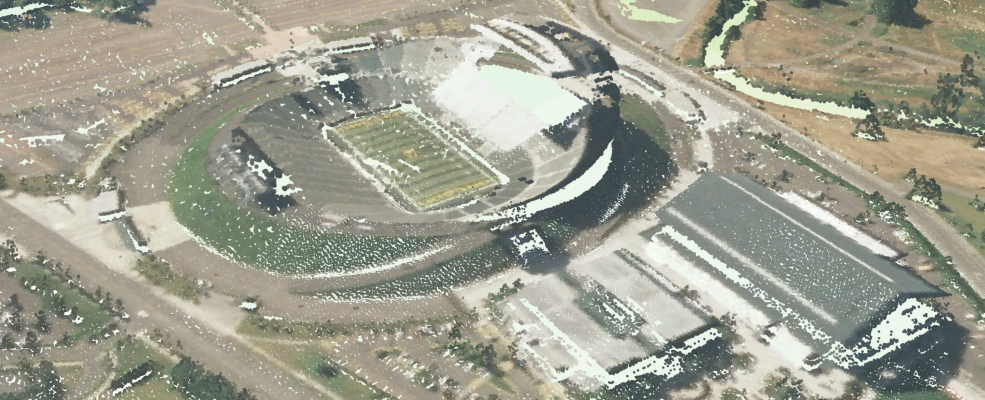

In [11]:
from arcgis.widgets import MapView
mv0b = MapView(item=ws_item, mode="3D")
mv0b

In [10]:
mv0b.extent = {  'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
                 'xmin': -13700550.876543041,
                 'ymin': 5474193.702954712,
                 'xmax': -13699185.234601548,
                 'ymax': 5474757.435437787}

## Step 2. Identify ground V.S. non-ground

The primary input for Digital Terrain Model (DTM) generation is a point cloud with ground vs. non-ground classifications. In this example, we will use an algorithm provided by PDAL, the Simple Morphological Filter technique to generate a ground surface.

In [ ]:
!pdal translate ./autzen.laz -o ./ground.laz smrf -v 4

If there is noise underneath the main surface, a terrain surface then generated will not be satisfactory. Here, when we visualize the output of this ground operation, we notice there’s still some noise. 

In order to remove the noise, we can stack the call to `SMRF` with a call to a the `filters.outlier` technique for denoising. First, let us start by removing the non-ground data to just view the ground data:

In [ ]:
!pdal translate ./autzen.laz -o ./ground.laz \
                smrf range \
                --filters.range.limits="Classification[2:2]" \
                -v 4


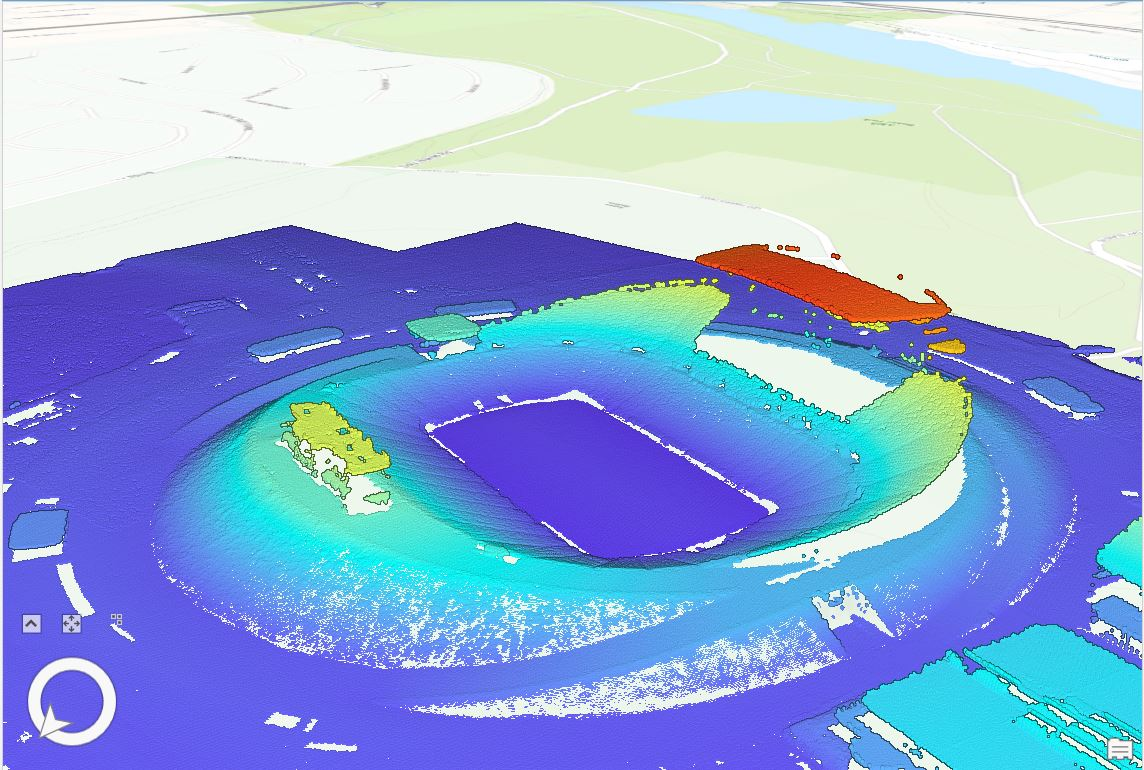

In [205]:
# display the ground

 Next, we will use the translate command to stack the `filters.outlier` and `filters.smrf` stages:

In [ ]:
!pdal translate ./autzen.laz -o ./denoised-ground-only.laz \
                outlier smrf range  \
                --filters.outlier.method="statistical" \
                --filters.outlier.mean_k=8 --filters.outlier.multiplier=3.0 \
                --filters.smrf.ignore="Classification[7:7]"  \
                --filters.range.limits="Classification[2:2]" \
                --writers.las.compression=true \
                --verbose 4

Here, the outlier filter `--filters.smrf.ignore="Classification[7:7]"` merely classifies outliers with a Classification value of 7. These outliers are then ignored during SMRF processing with the ignore option. Then, we add a range filter to extract only the ground returns (i.e., Classification value of 2) via `--filters.range.limits="Classification[2:2]"`. Compared to the results obtained from previous steps, the newest result is a more accurate representation of the ground returns.


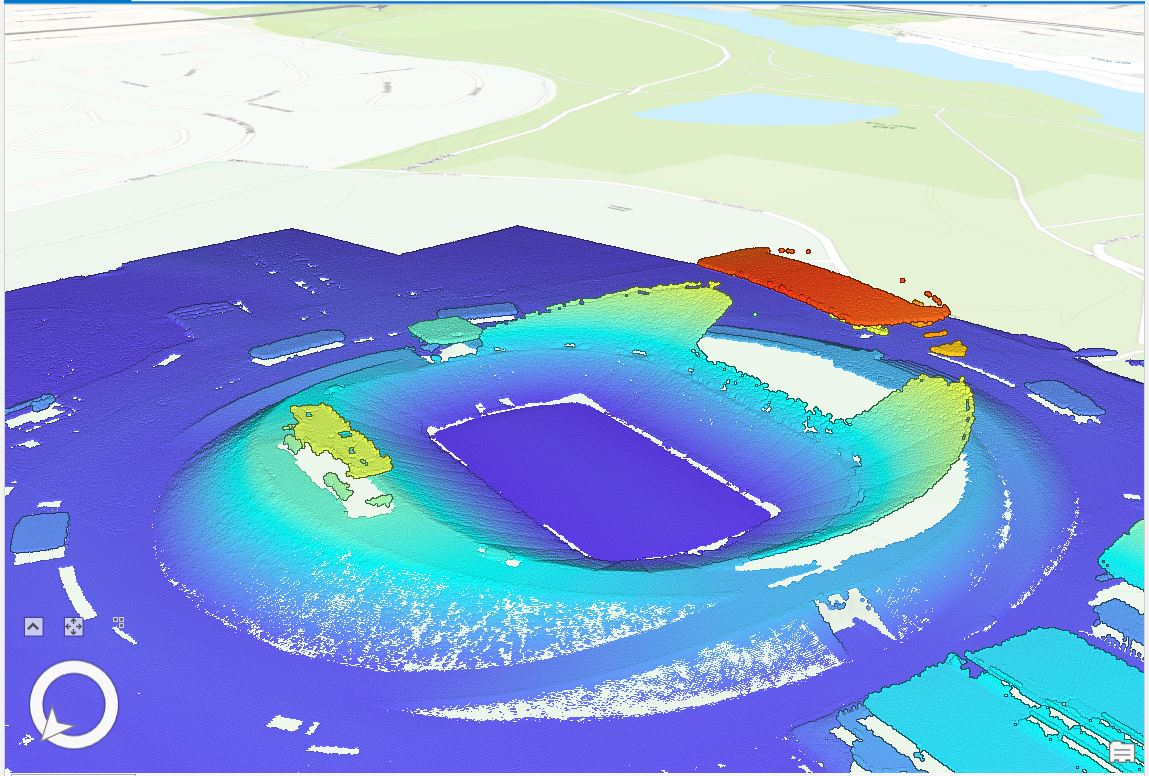

In [204]:
# display the .las file for denoised ground

Comparing the two images shown above, we can see that the denoised ground .las shows smoother and simplified points, edges and surfaces.

## Step 3. Generating a DTM

`PDAL` can also be used to generate an elevation model surface using the output from step 2, using PDAL’s `writers.gdal` operation, and `GDAL` to generate an elevation and hillshade surface from point cloud data. Here,
 - `denoised-ground-only` is the `LASzip` file we will clip. You should have created this output as in step 2.
 - The `writers.gdal` writer that bins the point cloud data into an elevation surface.

In [206]:
json_data = {
                "pipeline": [
                    "./denoised-ground-only.laz",
                    {
                        "filename":"./dtm.tif",
                        "gdaldriver":"GTiff",
                        "output_type":"all",
                        "resolution":"2.0",
                        "type": "writers.gdal"
                    }
                ]
            }

In [207]:
import json
with open('gdal.json', 'w', encoding='utf-8') as f:
    json.dump(json_data, f, ensure_ascii=False, indent=4)

Executing `pdal` commands against the newly created `gdal.json`, we then can see `dtm.tif` being created in the current working directory, which can be opened and viewed in ArcGIS Pro, or be published to ArcGIS Image Server and added to the notebook's map viewer.

In [ ]:
!pdal pipeline ./gdal.json


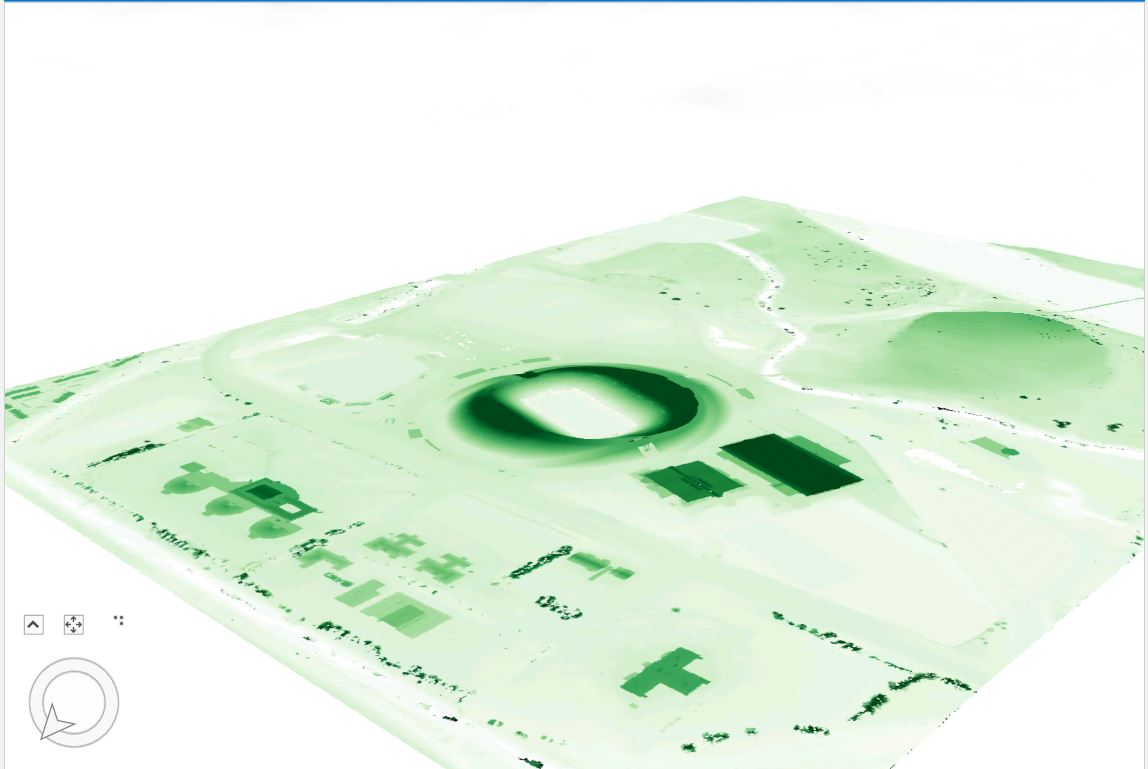

In [208]:
# dtm.tif displayed in ArcGIS Pro
# Pixels in higher elevation are in deeper green

`gdaldem hillshade` command can be used to create `hillshade` product out of `dtm.tif`, and the generated `hillshade.tif` can again be viewed in Pro or Map Widget:

In [ ]:
!gdaldem hillshade ./dtm.tif ./hillshade.tif \
-z 1.0 -s 1.0 -az 315.0 -alt 45.0 \
-of GTiff


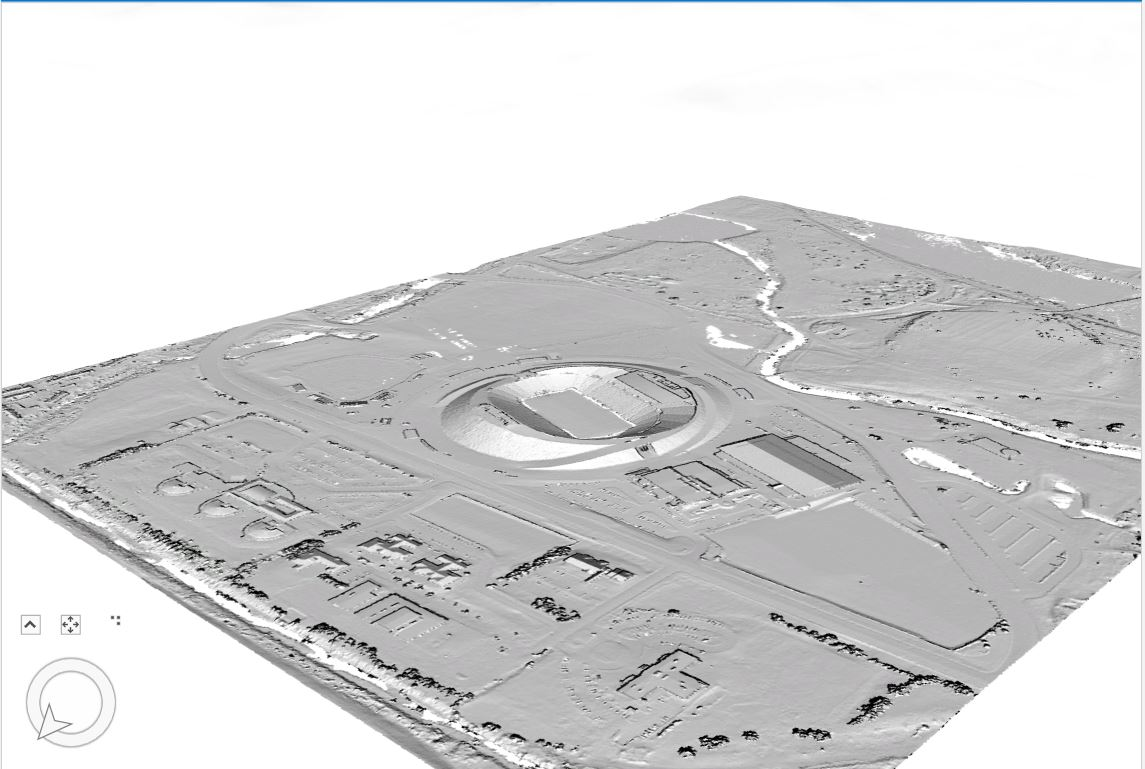

In [209]:
# hillshade.tif displayed in Pro
# pixels range from 1 to 255; Pixels in higher elevation are shown in lighter colors.

## Step 4. Reading data from EPT + Pipelined processing

Next, we will walk through a use case in which we use `PDAL`’s `readers.ept` to fetch data, filter it for noise using `filters.outlier`, classify the data as ground/not-ground using `filters.smrf`, and write out a digital terrain model (DTM)with `writers.gdal`. Once our elevation model is constructed, we will use GDAL's `gdaldem` operations to create hillshade, slope, and color relief (refer to Fig 2 for the diagram).

### 4.1 Create a file called dc.json with the following content:

```
{
	"pipeline": [
		{
			"bounds": "([-8576306.10, -8572306.10], [4703671.67, 4707671.67])",
			"filename": "https://s3-us-west-2.amazonaws.com/usgs-lidar-public/USGS_LPC_MD_VA_Sandy_NCR_2014_LAS_2015",
			"type": "readers.ept",
			"tag": "readdata"
		},
		{
			"limits": "Classification![7:7]",
			"type": "filters.range",
			"tag": "nonoise"
		},
		{
			"assignment": "Classification[:]=0",
			"tag": "wipeclasses",
			"type": "filters.assign"
		},
		{
			"out_srs": "EPSG:26915",
			"tag": "reprojectUTM",
			"type": "filters.reprojection"
		},
		{
			"tag": "groundify",
			"type": "filters.smrf"
		},
		{
			"limits": "Classification[2:2]",
			"type": "filters.range",
			"tag": "classify"
		},
		{
			"filename": "dc.laz",
			"inputs": [
				"classify"
			],
			"tag": "writerslas",
			"type": "writers.las"
		},
		{
			"filename": "dc.tif",
			"gdalopts": "tiled=yes,     compress=deflate",
			"inputs": [
				"writerslas"
			],
			"nodata": -9999,
			"output_type": "idw",
			"resolution": 1,
			"type": "writers.gdal",
			"window_size": 6
		}
	]
}
```

### 4.2 Stages walk-through

#### readers.ept

`readers.ept` reads the point cloud data from the EPT resource on AWS. We give it a URL (e.g. we used `https://s3-us-west-2.amazonaws.com/usgs-lidar-public/USGS_LPC_MD_VA_Sandy_NCR_2014_LAS_2015` here) to the root of the resource in the filename option, and we also give it a bounds object (e.g. `([-8576306.10, -8572306.10], [4703671.67, 4707671.67])`) to define the window in which we should select data from.

#### filters.range

The data we are selecting may contain noise properly classified, and we can use `filters.range` to keep all data that does not have a Classification Dimensions value of 7.

#### filters.assign

After removing points that have noise classifications, we need to reset all of the classification values in the point data. `filters.assign` takes the expression `Classification [:]=0` and assigns the Classification for each point to 0.

#### filters.reprojection

The data on the `AWS 3DEP Public Dataset` are stored in `Web Mercator coordinate system`, which is not suitable for many operations. We need to reproject them into an appropriate UTM coordinate system (`EPSG:26915`).

#### filters.smrf

The Simple Morphological Filter (`filters.smrf`) classifies points as ground or not-ground. `filters.smrf` provides a number of tuning options, but the defaults tend to work quite well for mixed urban environments on flat ground.

#### filters.range

After we have executed the `SMRF` filter, we only want to keep points that are actually classified as ground in our point stream. Selecting for points with `Classification[2:2]` does that for us (in the same time, remove any point that is not ground classification for our DTM generation).

#### writers.gdal

Having filtered our point data, we’re now ready to write a raster `DTM` with `writers.gdal`. Interesting options we choose here are to set the nodata value, specify only outputting the inverse distance weighted raster, and assigning a resolution of 1 (m).

#### writers.las

We can also write a `LAZ` file containing the same points that were used to make the elevation model in the section above.

### 4.3 Execute the Pipeline

Now that we understand what each stage does, let's execute the pipeline by invoking the PDAL pipeline command (Add the `--debug` option if you would like information about how PDAL is fetching and processing the data):

In [ ]:
!pdal pipeline dc.json --debug

### 4.4 Colorize the DEM

If a grayscale DEM is not the optimal result for you, your can also save a color scheme to dem-colors.txt, e.g.

```
# Color ramp for dc.tif
-6.212,250,250,250,255,-1.43508
-1.43507,230,230,230,255,3.34184
3.34185,209,209,209,255,8.11876
8.11877,189,189,189,255,12.89568
12.89569,168,168,168,255,17.6726
17.67261,148,148,148,255,22.44952
22.44953,128,128,128,255,27.22644
27.22645,107,107,107,255,32.00336
32.00337,87,87,87,255,36.78028
36.78029,66,66,66,255,41.5572
41.55721,46,46,46,255,46.33412
46.33413,159,223,250,255,51.11104
51.11105,94,139,156,255,55.88
```

Then invoke `gdaldem` to colorize a PNG file for your TIFF:

In [ ]:
!gdaldem color-relief dc.tif dem-colors.txt dc-color.png

And your raster would be viewed looking like:

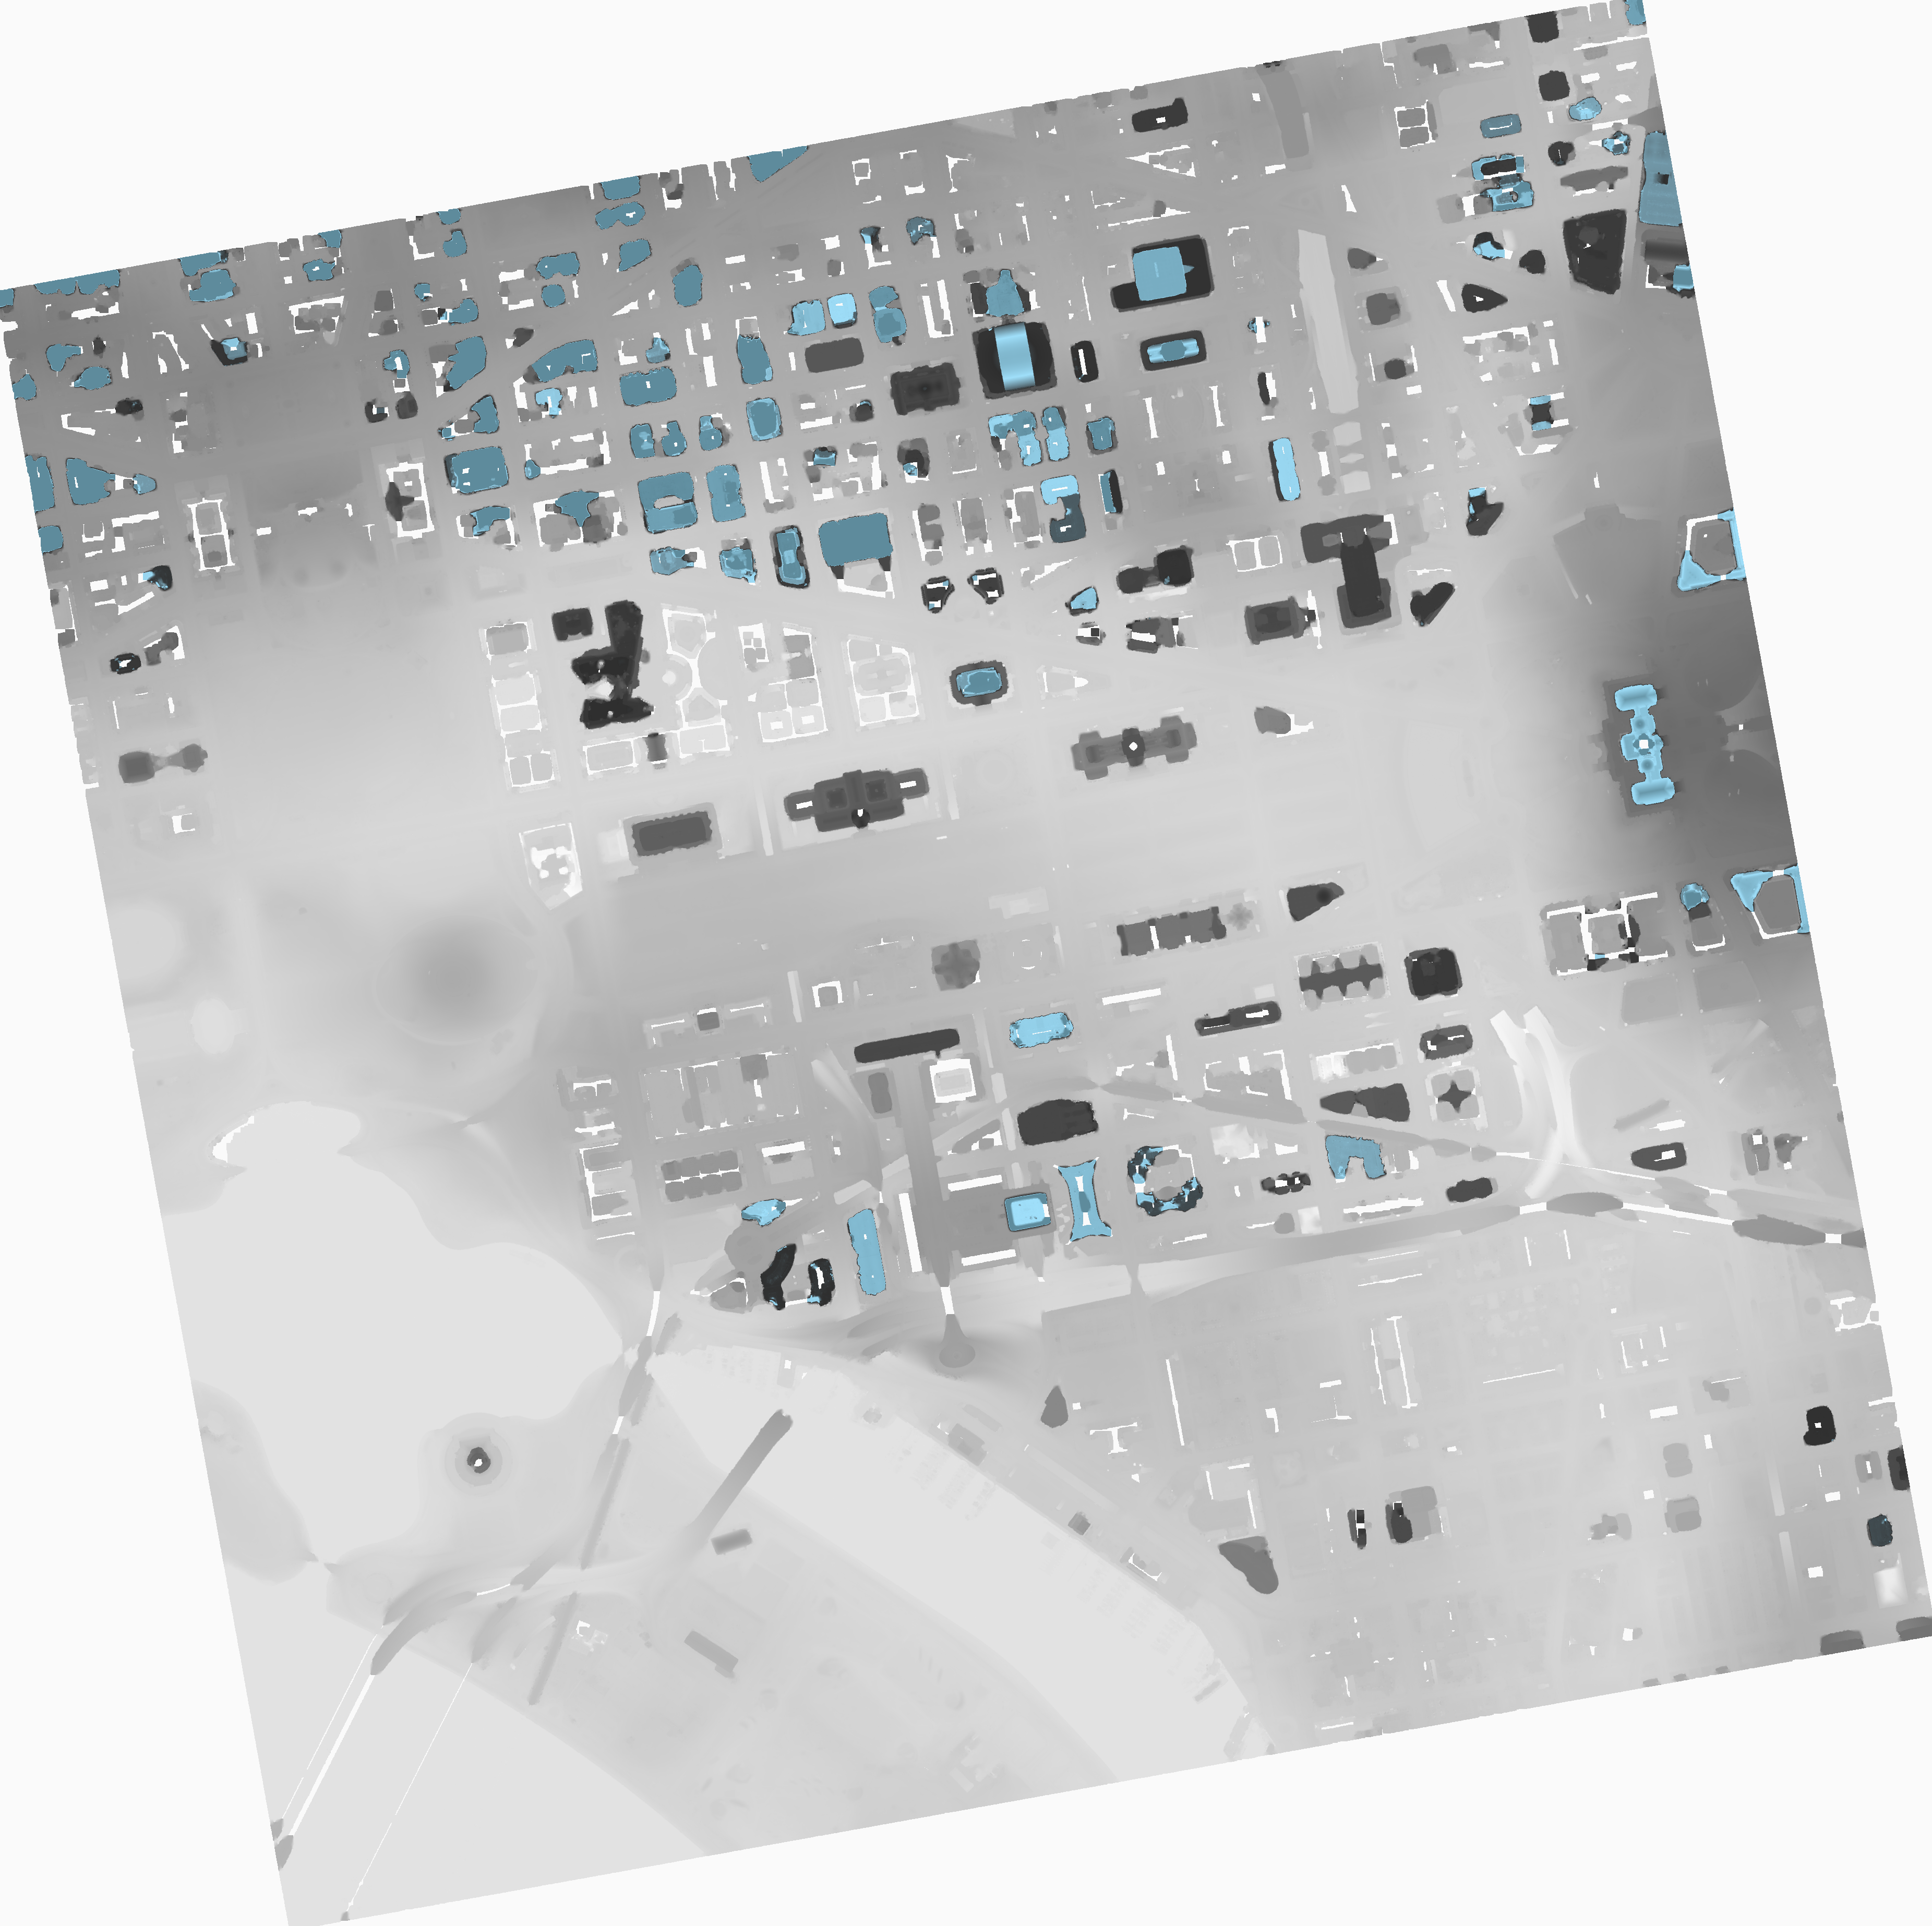

In [13]:
from IPython.display import Image
display(Image(filename='dc-color.png', height=800, width=800))

In this example, we have learned how to use Conda, Entwine, PDAL, and GDAL to read data from EPT resource (using PDAL’s readers.ept), filter it for noise using filters.outlier, classify the data as ground/not-ground using filters.smrf, and write out the DTM with writers.gdal. Also, GDAL gdaldem operations being called to create hillshade, slope, and color relief. All stages are put down in a JSON file, and later being executed by PDAL pipelines.

## References

[1] https://pdal.io/workshop/lidar-introduction.html?highlight=surface

[2] https://entwine.io/entwine-point-tile.html

[3] https://pdal.io/tutorial/iowa-entwine.html